In [4]:
# import subprocess
# subprocess.run([
#     "uv", "pip", "install",
#     "albumentations",
#     "opencv-python",
#     "pandas",
#     "pyyaml",
#     "matplotlib"
# ], check=True)

CompletedProcess(args=['uv', 'pip', 'install', 'albumentations', 'opencv-python', 'pandas', 'pyyaml', 'matplotlib'], returncode=0)

## Imports, Data loading and Model Initialization

In [2]:
import sys

sys.path.append("../src")

MODEL_NAME = "CIDAS/clipseg-rd64-refined"
RUN_NAME = "clipseg"

PROCESSED_ROOT = "../dataset/processed"
SPLITS_JSON = "../dataset/processed/splits.json"
PROMPTS_CSV = "../dataset/processed/prompts.csv"

IMAGE_SIZE = (352, 352)

EPOCHS = 30
BATCH_SIZE = 4
ACCUMULATION_STEPS = 4  # effective batch size = 4 * 4 = 16
LR = 1e-4
WARMUP_EPOCHS = 3
NEG_PROB = 0.3
SEED = 42
UNFREEZE_EPOCH = 10  # unfreeze last 2 encoder layers after this epoch

LOSS_TYPE = "bce_dice"
BCE_WEIGHT = 0.5
DICE_WEIGHT = 0.5
POS_WEIGHT = None

PATIENCE = 7

CKPT_DIR = f"../outputs/checkpoints/{RUN_NAME}"
PRED_DIR = f"../outputs/predictions/{RUN_NAME}"
VIZ_DIR = f"../outputs/visualisations/{RUN_NAME}"

In [3]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.amp import GradScaler, autocast
from tqdm import tqdm
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

from dataset import SegDataset, build_loaders
from augmentations import get_transform
from losses import get_loss
from metrics import MetricTracker, BestModelTracker
from utils import (
    get_device,
    count_parameters,
    save_checkpoint,
    load_checkpoint,
    save_predictions,
    visualise_predictions,
    save_results,
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [4]:
for path in [PROCESSED_ROOT, SPLITS_JSON, PROMPTS_CSV]:
    p = Path(path)
    print(f"{'OK' if p.exists() else 'MISSING'}  {path}")

OK  ../dataset/processed
OK  ../dataset/processed/splits.json
OK  ../dataset/processed/prompts.csv


In [ ]:
with open(SPLITS_JSON) as f:
    splits = json.load(f)

prompts_df = pd.read_csv(PROMPTS_CSV)

print(f"Splits loaded  seed={splits['seed']}")
print(
    f"  drywall  train={len(splits['drywall']['train'])}  val={len(splits['drywall']['val'])}  test={len(splits['drywall']['test'])}"
)
print(
    f"  cracks   train={len(splits['cracks']['train'])}  val={len(splits['cracks']['val'])}  test={len(splits['cracks']['test'])}"
)
print(f"Prompts loaded  {len(prompts_df)} rows")

Splits loaded  seed=42
  drywall  train=172  val=36  test=38
  cracks   train=778  val=166  test=168
Prompts loaded  1358 rows


In [ ]:
cfg = {
    "processed_root": PROCESSED_ROOT,
    "image_size": list(IMAGE_SIZE),
    "batch_size": BATCH_SIZE,
    "neg_prob": NEG_PROB,
}

processor = CLIPSegProcessor.from_pretrained(MODEL_NAME)

train_loader, val_loader, test_loader = build_loaders(
    cfg=cfg,
    prompts_df=prompts_df,
    splits=splits,
    transform_fn=lambda split, size: get_transform(split, size, model="clipseg"),
    processor=processor,
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Train sampler  drywall=172  cracks=778  ratio=4.5:1
Train batches : 238
Val batches   : 51
Test batches  : 206


In [7]:
batch = next(iter(train_loader))

print(
    f"pixel_values : {batch['pixel_values'].shape}  dtype={batch['pixel_values'].dtype}"
)
print(
    f"mask         : {batch['mask'].shape}  min={batch['mask'].min():.1f}  max={batch['mask'].max():.1f}"
)
print(f"input_ids    : {batch['input_ids'].shape}")
print(f"prompts      : {batch['prompt']}")
print(f"stems        : {batch['stem']}")

pixel_values : torch.Size([4, 3, 352, 352])  dtype=torch.float32
mask         : torch.Size([4, 352, 352])  min=0.0  max=1.0
input_ids    : torch.Size([4, 5])
prompts      : ['segment wall seam', 'segment crack', 'segment taping area', 'segment wall crack']
stems        : ['drywall_00160', 'drywall_00224', 'drywall_00194', 'cracks_00405']


In [8]:
device = get_device()

model = CLIPSegForImageSegmentation.from_pretrained(MODEL_NAME)
model = model.to(device)

count_parameters(model)

Using GPU: NVIDIA GeForce RTX 3060 Laptop GPU


Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Parameters  trainable : 150,747,746
            frozen    : 0
            total     : 150,747,746


(150747746, 0)

In [43]:
for param in model.parameters():
    param.requires_grad = False

for param in model.decoder.parameters():
    param.requires_grad = True

print("Encoder frozen. Decoder trainable.")
count_parameters(model)

Encoder frozen. Decoder trainable.
Parameters  trainable : 1,127,009
            frozen    : 149,620,737
            total     : 150,747,746


(1127009, 149620737)

In [ ]:
model.eval()
with torch.no_grad():
    out = model(
        pixel_values=batch["pixel_values"].to(device),
        input_ids=batch["input_ids"].to(device),
    )

print(f"Output logits shape : {out.logits.shape}")
print(f"Min / Max logits    : {out.logits.min():.3f} / {out.logits.max():.3f}")

Output logits shape : torch.Size([4, 352, 352])
Min / Max logits    : -8.727 / 1.107


In [ ]:
criterion = get_loss(
    {
        "loss_type": LOSS_TYPE,
        "bce_weight": BCE_WEIGHT,
        "dice_weight": DICE_WEIGHT,
        "pos_weight": POS_WEIGHT,
    }
)

optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=1e-4,
)


# warmup for first WARMUP_EPOCHS then cosine decay
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1.0 + np.cos(np.pi * progress))


scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler = GradScaler()  # for mixed precision

print(f"Loss      : {criterion.__class__.__name__}")
print(f"Optimizer : AdamW  lr={LR}  wd=1e-4")
print(f"Scheduler : Warmup({WARMUP_EPOCHS} epochs) + CosineDecay")
print(f"AMP       : enabled")
print(
    f"Grad accum: {ACCUMULATION_STEPS} steps  (effective batch={BATCH_SIZE * ACCUMULATION_STEPS})"
)

Loss      : BCEDiceLoss
Optimizer : AdamW  lr=0.0001  wd=1e-4
Scheduler : Warmup(3 epochs) + CosineDecay
AMP       : enabled
Grad accum: 4 steps  (effective batch=16)


## Training the Model 

In [ ]:
Path(CKPT_DIR).mkdir(parents=True, exist_ok=True)

best_tracker = BestModelTracker(metric="iou", patience=PATIENCE)
history = {"train": [], "val": []}

for epoch in range(1, EPOCHS + 1):
    # unfreeze last 2 encoder layers after UNFREEZE_EPOCH
    if epoch == UNFREEZE_EPOCH + 1:
        trainable_layers = [
            model.clip.vision_model.encoder.layers[-1],
            model.clip.vision_model.encoder.layers[-2],
        ]
        for layer in trainable_layers:
            for param in layer.parameters():
                param.requires_grad = True
        print(f"\nEpoch {epoch}: unfroze last 2 vision encoder layers")
        count_parameters(model)

    # training
    model.train()
    train_tracker = MetricTracker()
    optimizer.zero_grad()

    train_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f"Epoch {epoch:02d}/{EPOCHS} [train]",
        ncols=100,
        leave=False,
    )

    for step, batch in train_bar:
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        masks = batch["mask"].to(device)

        with autocast("cuda"):
            out = model(pixel_values=pixel_values, input_ids=input_ids)
            logits = out.logits.unsqueeze(1)

            if logits.shape[-2:] != masks.shape[-2:]:
                logits = F.interpolate(
                    logits, size=masks.shape[-2:], mode="bilinear", align_corners=False
                )

            loss = criterion(logits, masks) / ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % ACCUMULATION_STEPS == 0 or (step + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        train_tracker.update(logits, masks, loss=loss.item() * ACCUMULATION_STEPS)

        # live loss in tqdm bar
        train_bar.set_postfix(
            {
                "loss": f"{loss.item() * ACCUMULATION_STEPS:.4f}",
                "lr": f"{optimizer.param_groups[0]['lr']:.2e}",
            }
        )

    # validation
    model.eval()
    val_tracker = MetricTracker()

    val_bar = tqdm(
        val_loader,
        desc=f"Epoch {epoch:02d}/{EPOCHS} [val]  ",
        ncols=100,
        leave=False,
    )

    with torch.no_grad():
        for batch in val_bar:
            pixel_values = batch["pixel_values"].to(device)
            input_ids = batch["input_ids"].to(device)
            masks = batch["mask"].to(device)

            with autocast("cuda"):
                out = model(pixel_values=pixel_values, input_ids=input_ids)
                logits = out.logits.unsqueeze(1)

                if logits.shape[-2:] != masks.shape[-2:]:
                    logits = F.interpolate(
                        logits,
                        size=masks.shape[-2:],
                        mode="bilinear",
                        align_corners=False,
                    )

                loss = criterion(logits, masks)

            val_tracker.update(logits, masks, loss=loss.item())

            val_bar.set_postfix(
                {
                    "loss": f"{loss.item():.4f}",
                }
            )

    scheduler.step()

    train_metrics = train_tracker.compute()
    val_metrics = val_tracker.compute()
    history["train"].append(train_metrics)
    history["val"].append(val_metrics)

    # one clean summary line per epoch
    print(
        f"Epoch {epoch:02d}/{EPOCHS}  "
        f"lr={optimizer.param_groups[0]['lr']:.2e}  "
        f"train  {train_tracker.pretty()}  |  "
        f"val  {val_tracker.pretty()}  "
        f"[{best_tracker.status()}]"
    )

    if best_tracker.is_best(val_metrics):
        save_checkpoint(model, optimizer, epoch, val_metrics, f"{CKPT_DIR}/best.pth")
        print(f"checkpoint saved")

    if best_tracker.should_stop():
        print(f"\nEarly stopping triggered at epoch {epoch}")
        break

Epoch 01/30  lr=6.67e-05  train  loss=0.5058  iou=0.3891  dice=0.4537  prec=0.7555  rec=0.5199  |  val  loss=0.4438  iou=0.2647  dice=0.3760  prec=0.6660  rec=0.4367  [best_iou=-inf  no_improve=0/7]
checkpoint saved


Epoch 02/30  lr=1.00e-04  train  loss=0.4464  iou=0.3199  dice=0.4030  prec=0.5061  rec=0.6767  |  val  loss=0.3851  iou=0.3338  dice=0.4629  prec=0.5586  rec=0.5906  [best_iou=0.2647  no_improve=0/7]
checkpoint saved


Epoch 03/30  lr=1.00e-04  train  loss=0.3659  iou=0.4273  dice=0.5173  prec=0.5735  rec=0.7266  |  val  loss=0.4003  iou=0.3651  dice=0.5040  prec=0.5569  rec=0.6409  [best_iou=0.3338  no_improve=0/7]
checkpoint saved


Epoch 04/30  lr=9.97e-05  train  loss=0.3133  iou=0.4718  dice=0.5637  prec=0.6198  rec=0.7362  |  val  loss=0.3565  iou=0.3709  dice=0.5111  prec=0.5753  rec=0.6348  [best_iou=0.3651  no_improve=0/7]
checkpoint saved


Epoch 05/30  lr=9.87e-05  train  loss=0.3060  iou=0.4826  dice=0.5795  prec=0.6283  rec=0.7531  |  val  loss=0.3372  iou=0.3963  dice=0.5418  prec=0.5728  rec=0.6881  [best_iou=0.3709  no_improve=0/7]
checkpoint saved


...

Epoch 26/30  lr=5.32e-06  train  loss=0.2374  iou=0.5627  dice=0.6634  prec=0.6796  rec=0.8036  |  val  loss=0.2989  iou=0.4429  dice=0.5952  prec=0.6230  rec=0.7075  [best_iou=0.4409  no_improve=0/7]
checkpoint saved


Epoch 27/30  lr=3.02e-06  train  loss=0.2434  iou=0.5536  dice=0.6553  prec=0.6785  rec=0.7948  |  val  loss=0.2993  iou=0.4429  dice=0.5938  prec=0.6156  rec=0.7101  [best_iou=0.4429  no_improve=0/7]


Epoch 28/30  lr=1.35e-06  train  loss=0.2401  iou=0.5623  dice=0.6652  prec=0.6847  rec=0.7973  |  val  loss=0.2983  iou=0.4432  dice=0.5962  prec=0.6143  rec=0.7170  [best_iou=0.4429  no_improve=1/7]
checkpoint saved


Epoch 29/30  lr=3.38e-07  train  loss=0.2440  iou=0.5533  dice=0.6574  prec=0.6748  rec=0.7994  |  val  loss=0.2992  iou=0.4427  dice=0.5949  prec=0.6167  rec=0.7149  [best_iou=0.4432  no_improve=0/7]


Epoch 30/30  lr=0.00e+00  train  loss=0.2533  iou=0.5452  dice=0.6488  prec=0.6709  rec=0.7943  |  val  loss=0.2990  iou=0.4436  dice=0.5959  prec=0.6179  rec=0.7141  [best_iou=0.4432  no_improve=1/7]
checkpoint saved


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x0000021A1530F1A0>
Traceback (most recent call last):
  File "c:\Users\aatal\Documents\Projects\origin_assessment\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "c:\Users\aatal\Documents\Projects\origin_assessment\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1665, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


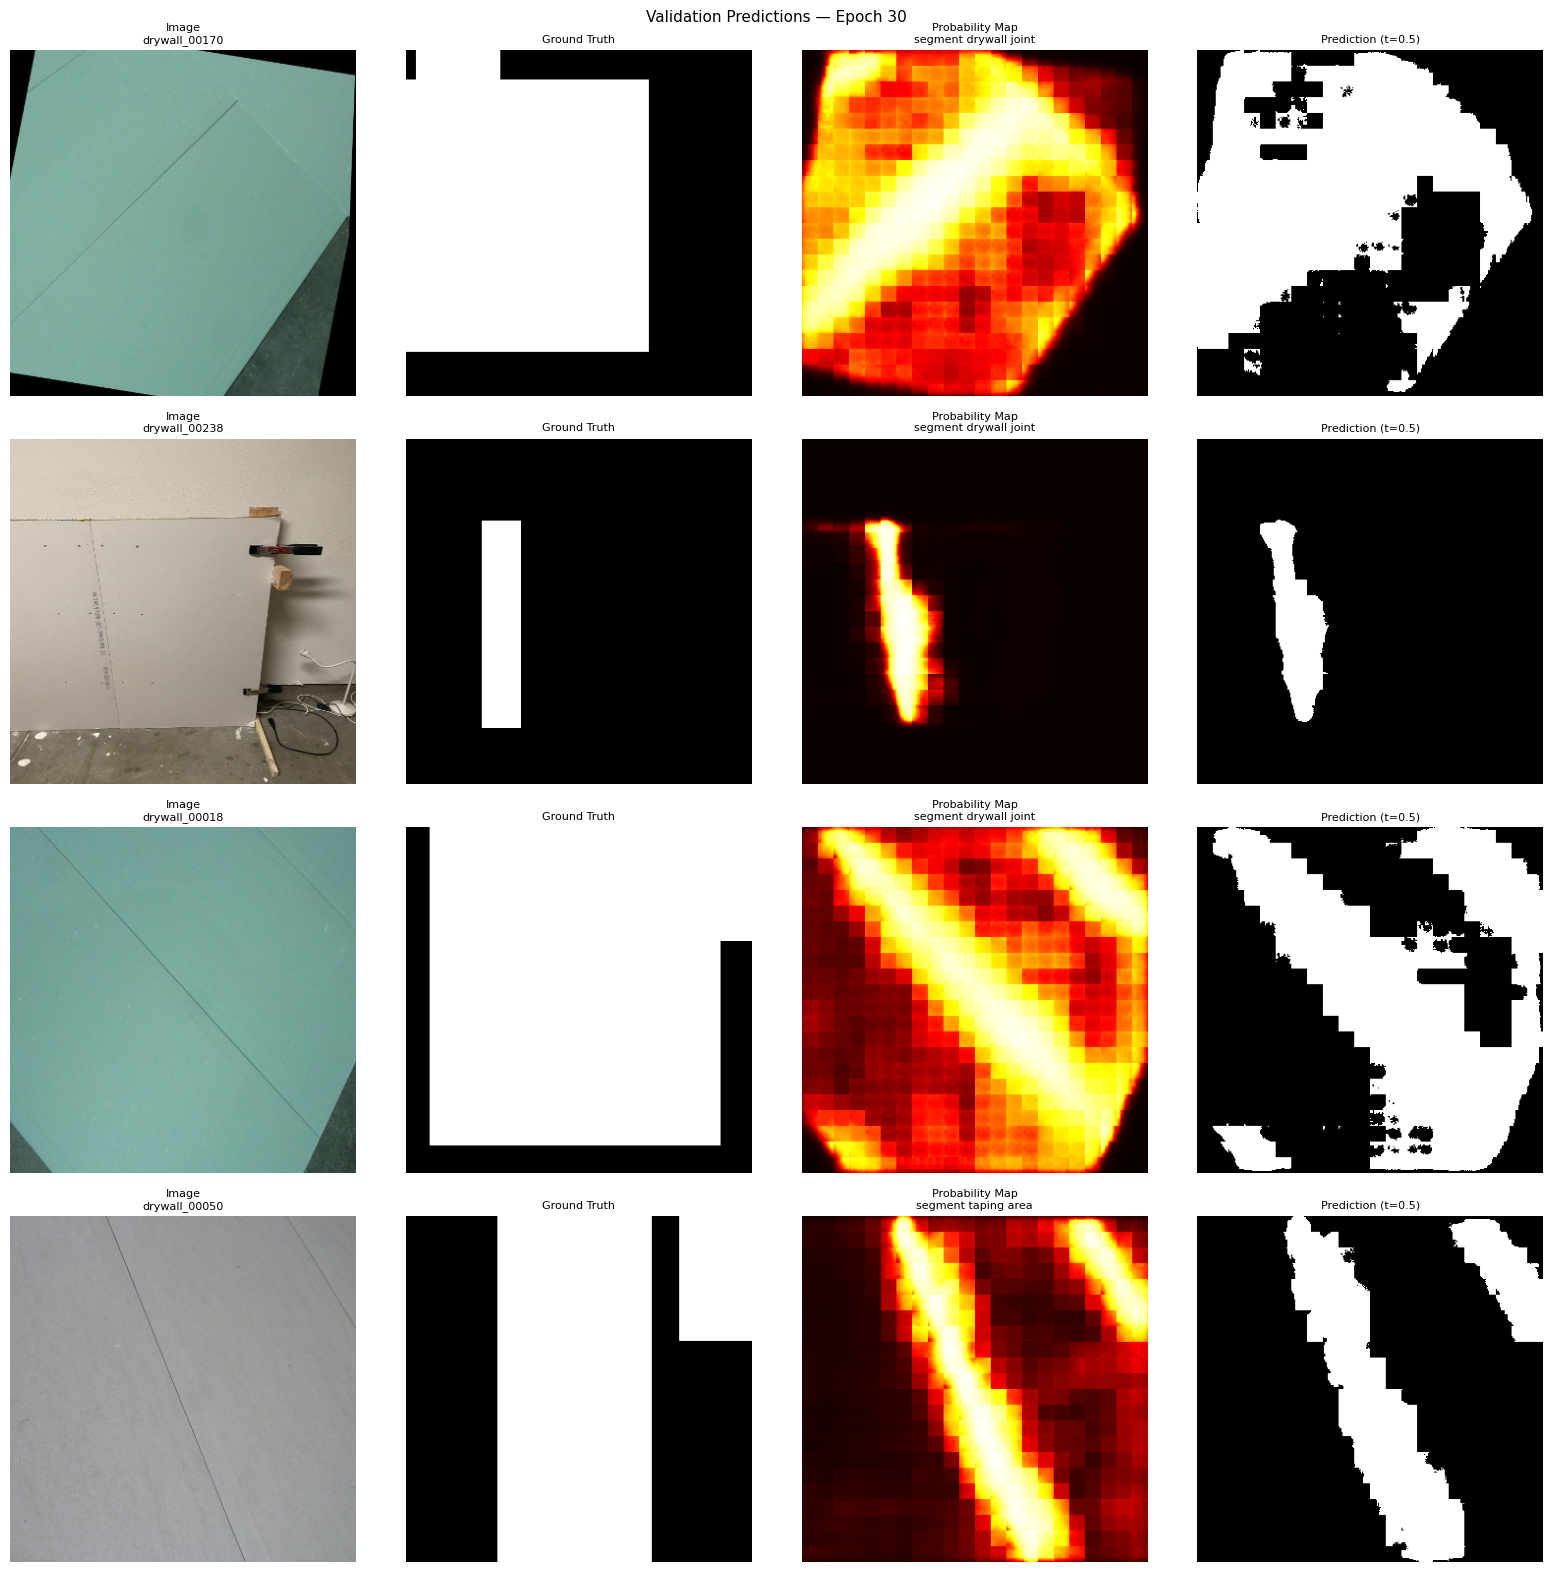

In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F


def show_predictions(model, loader, device, n=4, threshold=0.5):
    model.eval()
    batch = next(iter(loader))

    pixel_values = batch["pixel_values"].to(device)
    input_ids = batch["input_ids"].to(device)
    masks = batch["mask"]
    prompts = batch["prompt"]
    stems = batch["stem"]

    with torch.no_grad():
        with torch.amp.autocast("cuda"):
            out = model(pixel_values=pixel_values, input_ids=input_ids)
            logits = out.logits.unsqueeze(1)
            if logits.shape[-2:] != masks.shape[-2:]:
                logits = F.interpolate(
                    logits, size=masks.shape[-2:], mode="bilinear", align_corners=False
                )

    probs = torch.sigmoid(logits).squeeze(1).cpu()
    pred_bin = (probs >= threshold).float()

    n = min(n, pixel_values.size(0))
    fig, axes = plt.subplots(n, 4, figsize=(16, 4 * n))

    if n == 1:
        axes = axes[np.newaxis, :]

    for i in range(n):
        # denormalise image for display
        img = pixel_values[i].cpu()
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img = (img * std + mean).permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        gt = masks[i].numpy()
        pred = pred_bin[i].numpy()
        prob_map = probs[i].numpy()

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Image\n{stems[i]}", fontsize=8)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(gt, cmap="gray", vmin=0, vmax=1)
        axes[i, 1].set_title("Ground Truth", fontsize=8)
        axes[i, 1].axis("off")

        axes[i, 2].imshow(prob_map, cmap="hot", vmin=0, vmax=1)
        axes[i, 2].set_title(f"Probability Map\n{prompts[i]}", fontsize=8)
        axes[i, 2].axis("off")

        axes[i, 3].imshow(pred, cmap="gray", vmin=0, vmax=1)
        axes[i, 3].set_title(f"Prediction (t={threshold})", fontsize=8)
        axes[i, 3].axis("off")

    plt.suptitle(f"Validation Predictions — Epoch {epoch}", fontsize=11)
    plt.tight_layout()
    plt.show()


show_predictions(model, val_loader, device, n=4)

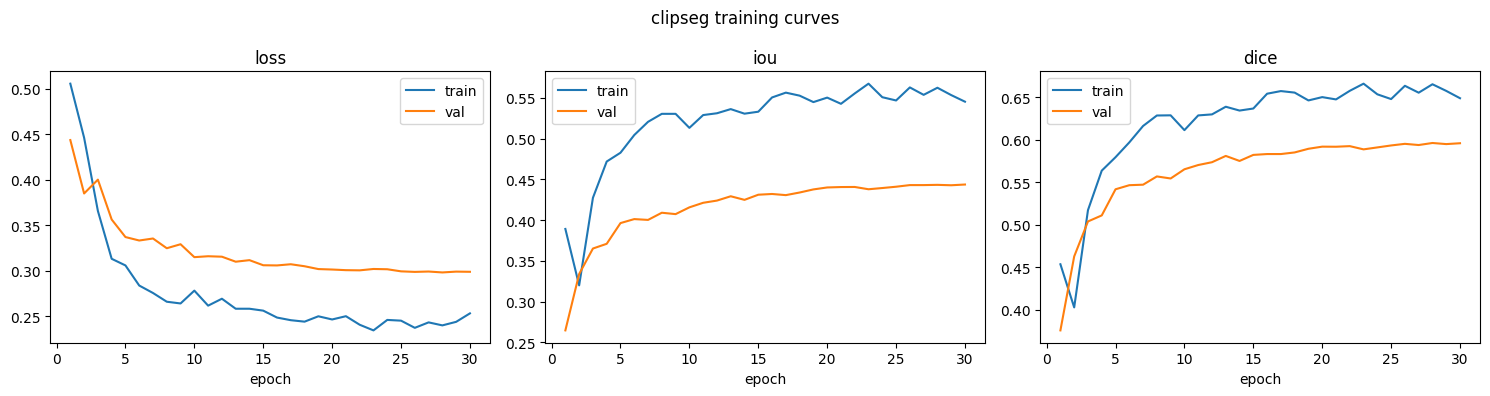

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ["loss", "iou", "dice"]):
    ax.plot(epochs, [m[metric] for m in history["train"]], label="train")
    ax.plot(epochs, [m[metric] for m in history["val"]], label="val")
    ax.set_title(metric)
    ax.set_xlabel("epoch")
    ax.legend()

plt.suptitle(f"{RUN_NAME} training curves")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import torch

# bypass the utils function entirely and load directly
ckpt = torch.load(f"{CKPT_DIR}/best.pth", map_location=device, weights_only=False)
model.load_state_dict(ckpt["state_dict"])
best_val = ckpt.get("metrics", {})
epoch = ckpt.get("epoch", 0)
print(f"Loaded best checkpoint  epoch={epoch}  val_iou={best_val['iou']}")

model.eval()
test_tracker = MetricTracker()

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        masks = batch["mask"].to(device)

        out = model(pixel_values=pixel_values, input_ids=input_ids)
        logits = out.logits.unsqueeze(1)

        if logits.shape[-2:] != masks.shape[-2:]:
            logits = F.interpolate(
                logits, size=masks.shape[-2:], mode="bilinear", align_corners=False
            )

        test_tracker.update(logits, masks)

test_metrics = test_tracker.compute()
print(f"\nTest results")
print(f"  IoU       : {test_metrics['iou']}")
print(f"  Dice      : {test_metrics['dice']}")
print(f"  Precision : {test_metrics['precision']}")
print(f"  Recall    : {test_metrics['recall']}")

Loaded best checkpoint  epoch=30  val_iou=0.4436

Test results
  IoU       : 0.4395
  Dice      : 0.5896
  Precision : 0.643
  Recall    : 0.6855


In [ ]:
Path(PRED_DIR).mkdir(parents=True, exist_ok=True)
Path(VIZ_DIR).mkdir(parents=True, exist_ok=True)

model.eval()
viz_saved = False

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        masks = batch["mask"].to(device)

        out = model(pixel_values=pixel_values, input_ids=input_ids)
        logits = out.logits.unsqueeze(1)

        if logits.shape[-2:] != masks.shape[-2:]:
            logits = F.interpolate(
                logits, size=masks.shape[-2:], mode="bilinear", align_corners=False
            )

        save_predictions(logits, batch["stem"], batch["prompt"], PRED_DIR)

        if not viz_saved:
            visualise_predictions(
                pixel_values,
                masks,
                logits,
                batch["prompt"],
                n=4,
                save_path=f"{VIZ_DIR}/sample_predictions.png",
            )
            viz_saved = True

print(f"Predictions saved → {PRED_DIR}")
print(f"Visualisations  → {VIZ_DIR}")

Predictions saved → ../outputs/predictions/clipseg
Visualisations  → ../outputs/visualisations/clipseg


In [ ]:
results = {
    RUN_NAME: {
        "val": best_val,
        "test": test_metrics,
    }
}

save_results(results, "../outputs/metrics/results.json")

Results saved → ../outputs/metrics/results.json


In [ ]:
# evaluate per prompt type to see where the model struggles
from collections import defaultdict

model.eval()
per_class = defaultdict(lambda: {"iou": [], "dice": []})

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        masks = batch["mask"].to(device)
        prompts = batch["prompt"]

        out = model(pixel_values=pixel_values, input_ids=input_ids)
        logits = out.logits.unsqueeze(1)
        if logits.shape[-2:] != masks.shape[-2:]:
            logits = F.interpolate(
                logits, size=masks.shape[-2:], mode="bilinear", align_corners=False
            )

        probs = torch.sigmoid(logits).squeeze(1)
        pred_bin = (probs >= 0.5).float()

        for i, prompt in enumerate(prompts):
            p = pred_bin[i]
            gt = masks[i]
            inter = (p * gt).sum()
            union = (p + gt).clamp(0, 1).sum()
            iou = (inter / (union + 1e-6)).item()
            dice = (2 * inter / (p.sum() + gt.sum() + 1e-6)).item()
            key = "crack" if "crack" in prompt.lower() else "drywall"
            per_class[key]["iou"].append(iou)
            per_class[key]["dice"].append(dice)

for cls, vals in per_class.items():
    avg_iou = sum(vals["iou"]) / len(vals["iou"])
    avg_dice = sum(vals["dice"]) / len(vals["dice"])
    print(f"{cls:10s}  IoU={avg_iou:.4f}  Dice={avg_dice:.4f}  n={len(vals['iou'])}")

drywall     IoU=0.4466  Dice=0.6017  n=38
crack       IoU=0.4382  Dice=0.5863  n=168


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt = torch.load(f"{CKPT_DIR}/best.pth", map_location=device, weights_only=False)
model.load_state_dict(ckpt["state_dict"])
model = model.to(device)
model.eval()

best_val = ckpt.get("metrics", {})
epoch = ckpt.get("epoch", 0)
print(f"Loaded  epoch={epoch}  val_iou={best_val.get('iou', 'N/A')}")

Loaded  epoch=30  val_iou=0.4436


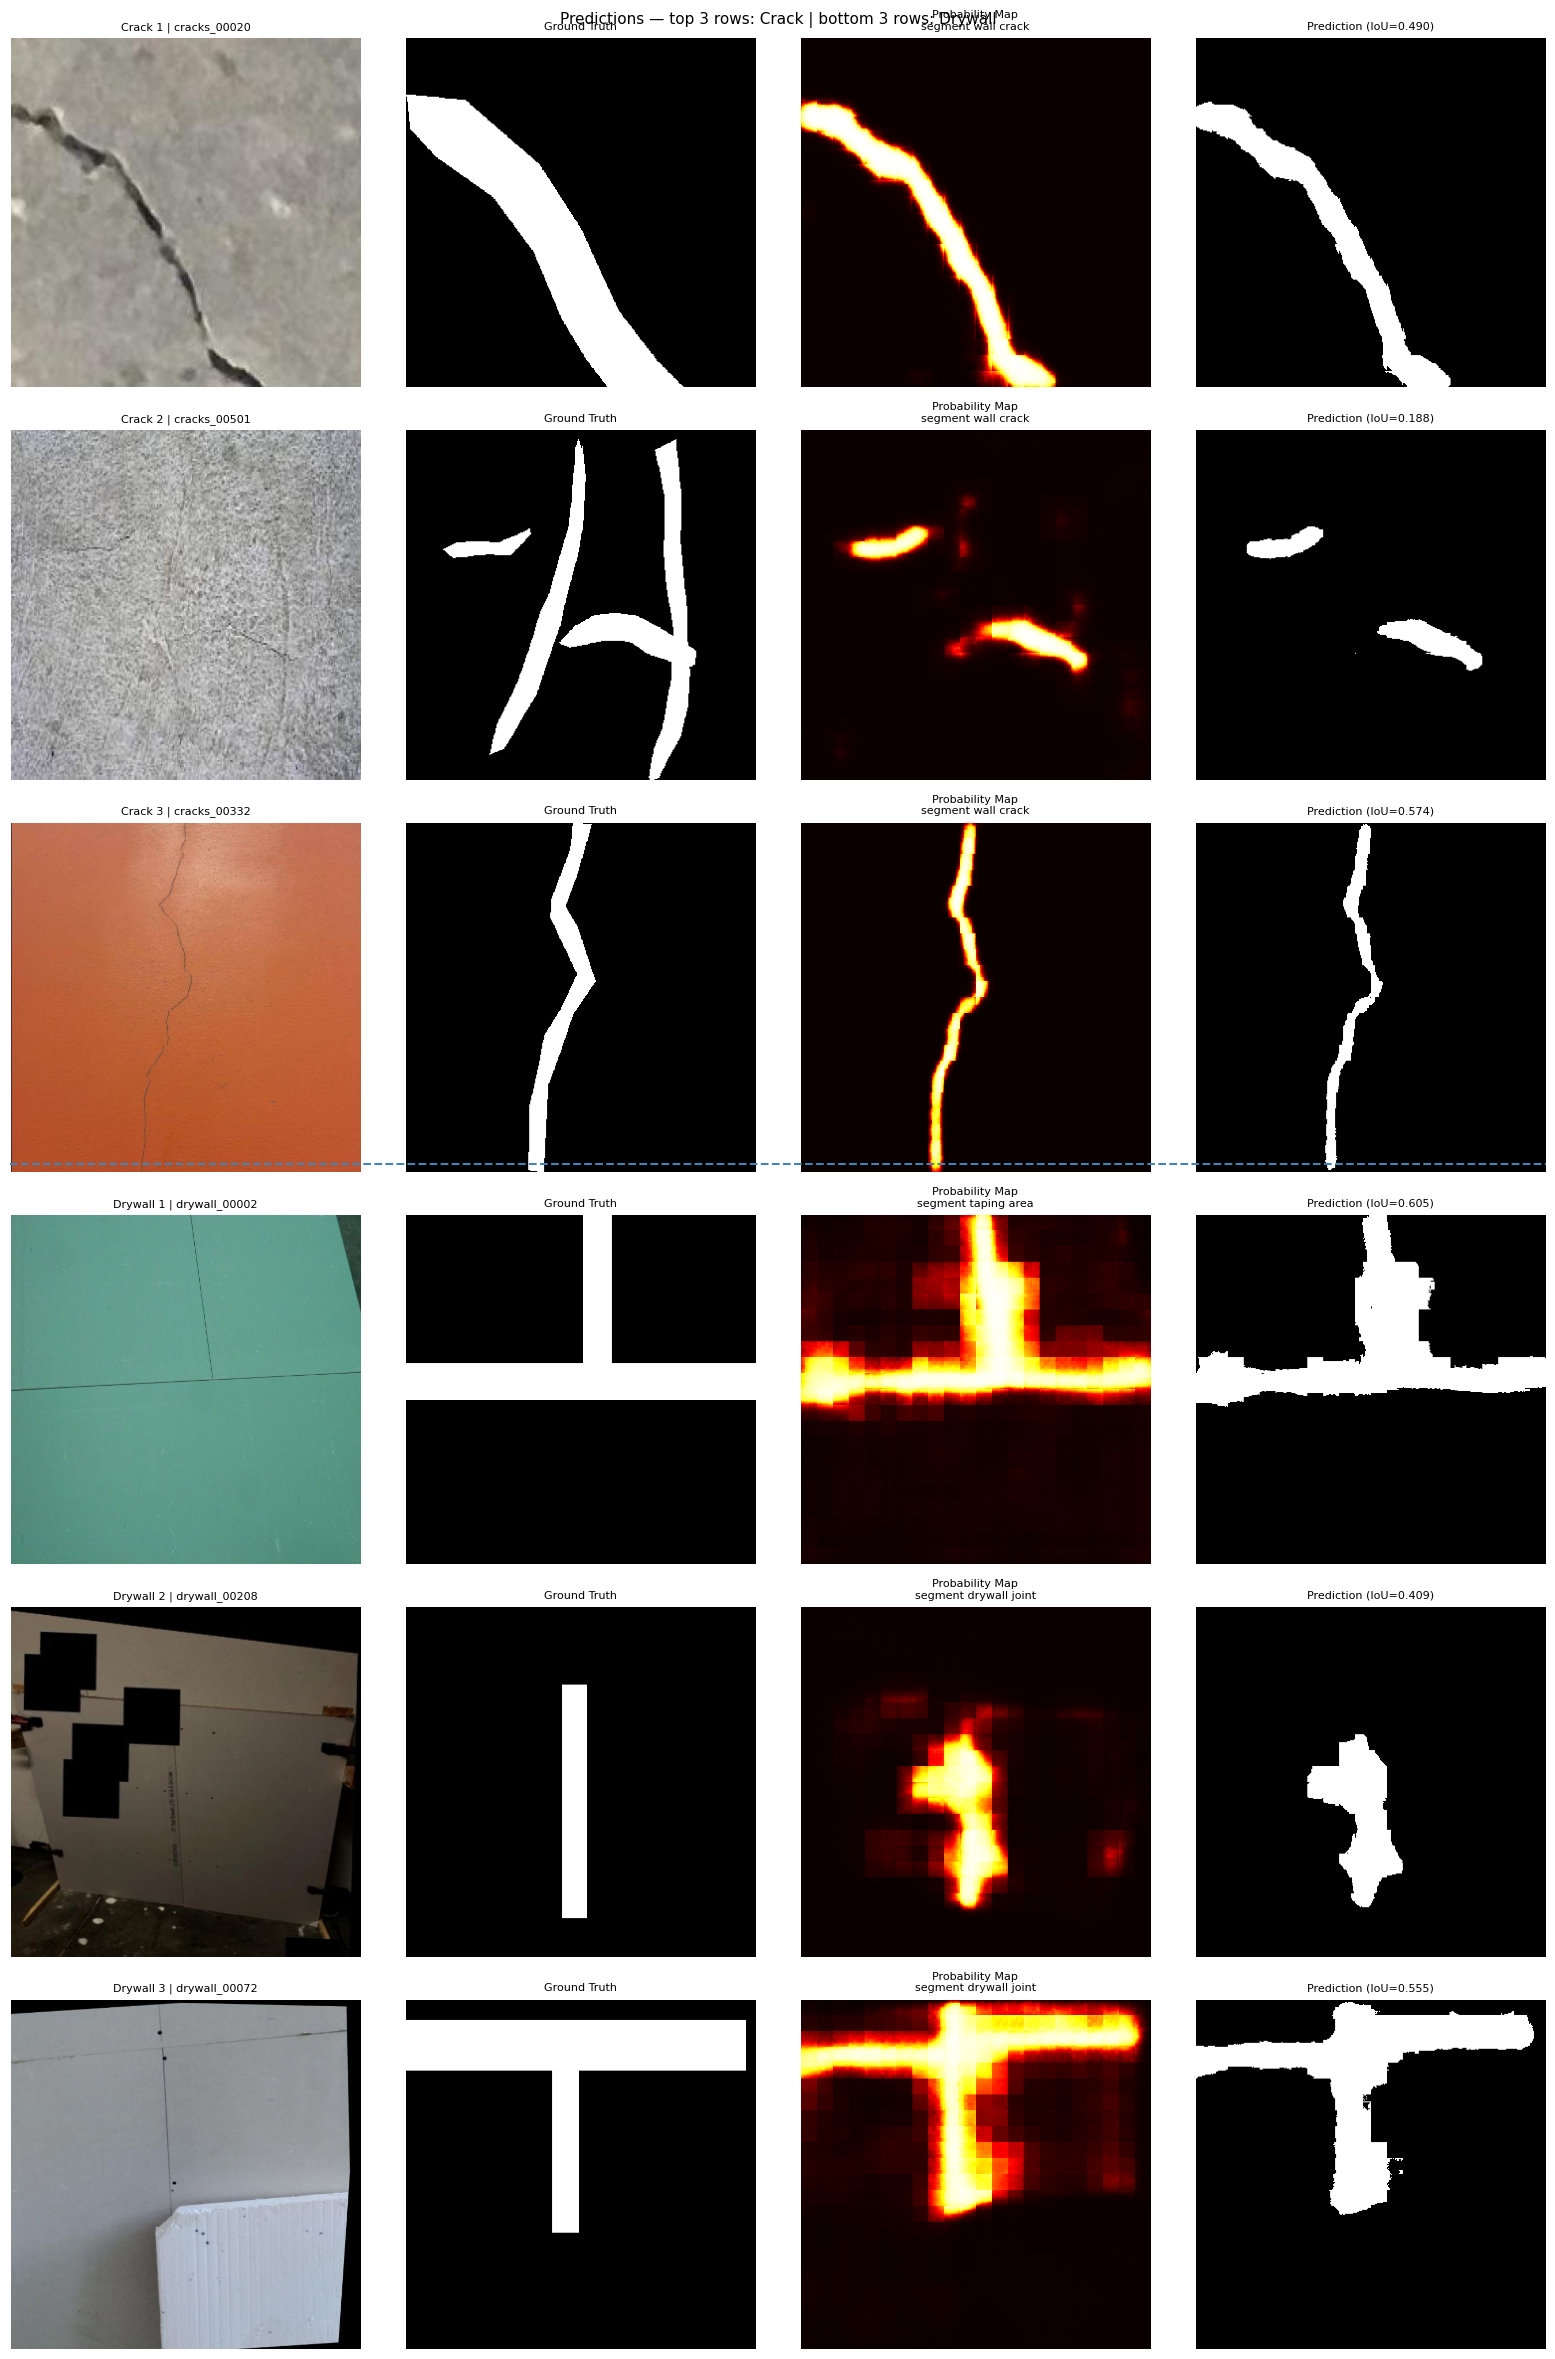

Saved → ../outputs/visualisations/clipseg/sample_predictions.png


In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np


def show_predictions_both_classes(model, loader, device, n_per_class=3, threshold=0.5):
    model.eval()

    # ── collect n_per_class samples from each class ──────────────────────────
    crack_samples = []
    drywall_samples = []

    for batch in loader:
        for idx, prompt in enumerate(batch["prompt"]):
            cls = "crack" if "crack" in prompt.lower() else "drywall"

            sample = {
                "pixel_values": batch["pixel_values"][idx : idx + 1],
                "input_ids": batch["input_ids"][idx : idx + 1],
                "mask": batch["mask"][idx : idx + 1],
                "prompt": prompt,
                "stem": batch["stem"][idx],
            }

            if cls == "crack" and len(crack_samples) < n_per_class:
                crack_samples.append(sample)
            if cls == "drywall" and len(drywall_samples) < n_per_class:
                drywall_samples.append(sample)

        if len(crack_samples) == n_per_class and len(drywall_samples) == n_per_class:
            break

    all_samples = crack_samples + drywall_samples  # crack rows first
    total = len(all_samples)

    # ── run inference on each sample ─────────────────────────────────────────
    all_probs = []
    all_preds = []

    with torch.no_grad():
        with torch.amp.autocast("cuda"):
            for s in all_samples:
                pv = s["pixel_values"].to(device)
                ids = s["input_ids"].to(device)
                out = model(pixel_values=pv, input_ids=ids)
                logits = out.logits.unsqueeze(1)
                prob = torch.sigmoid(logits).squeeze(1).cpu()
                all_probs.append(prob)
                all_preds.append((prob >= threshold).float())

    # ── plot: total rows x 4 cols ─────────────────────────────────────────────
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    fig, axes = plt.subplots(total, 4, figsize=(16, 4 * total))
    if total == 1:
        axes = axes[np.newaxis, :]

    for i, s in enumerate(all_samples):
        # denormalise image
        img = s["pixel_values"][0].cpu()
        img = (img * std + mean).permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        gt = s["mask"][0].numpy()
        prob_map = all_probs[i][0].numpy()
        pred = all_preds[i][0].numpy()

        # per-image IoU
        inter = float((all_preds[i][0] * s["mask"][0]).sum())
        union = float(((all_preds[i][0] + s["mask"][0]).clamp(0, 1)).sum())
        iou = inter / (union + 1e-6)

        # row label
        cls_label = "Crack" if i < n_per_class else "Drywall"
        row_num = (i % n_per_class) + 1

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"{cls_label} {row_num} | {s['stem']}", fontsize=8)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(gt, cmap="gray", vmin=0, vmax=1)
        axes[i, 1].set_title("Ground Truth", fontsize=8)
        axes[i, 1].axis("off")

        axes[i, 2].imshow(prob_map, cmap="hot", vmin=0, vmax=1)
        axes[i, 2].set_title(f"Probability Map\n{s['prompt']}", fontsize=8)
        axes[i, 2].axis("off")

        axes[i, 3].imshow(pred, cmap="gray", vmin=0, vmax=1)
        axes[i, 3].set_title(f"Prediction (IoU={iou:.3f})", fontsize=8)
        axes[i, 3].axis("off")

    # dashed divider between crack and drywall rows
    divider_y = 1.0 - (n_per_class / total)
    fig.add_artist(
        plt.Line2D(
            [0.02, 0.98],
            [divider_y, divider_y],
            transform=fig.transFigure,
            color="steelblue",
            linewidth=1.5,
            linestyle="--",
        )
    )

    plt.suptitle(
        f"Predictions — top {n_per_class} rows: Crack | bottom {n_per_class} rows: Drywall",
        fontsize=11,
    )
    plt.tight_layout()
    plt.savefig(f"{VIZ_DIR}/sample_predictions.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved → {VIZ_DIR}/sample_predictions.png")


show_predictions_both_classes(model, test_loader, device, n_per_class=3)

In [12]:
import os

model.eval()
dummy_batch = next(iter(test_loader))
dummy_pixels = dummy_batch["pixel_values"][:1].to(device)
dummy_ids = dummy_batch["input_ids"][:1].to(device)

for _ in range(10):
    with torch.no_grad():
        _ = model(pixel_values=dummy_pixels, input_ids=dummy_ids)

starter = torch.cuda.Event(enable_timing=True)
ender = torch.cuda.Event(enable_timing=True)
times = []

with torch.no_grad():
    for _ in range(50):
        starter.record()
        _ = model(pixel_values=dummy_pixels, input_ids=dummy_ids)
        ender.record()
        torch.cuda.synchronize()
        times.append(starter.elapsed_time(ender))

ckpt_mb = os.path.getsize(f"{CKPT_DIR}/best.pth") / 1024 / 1024
total_params = sum(p.numel() for p in model.parameters())

print(f"Inference  avg={np.mean(times):.1f}ms  std={np.std(times):.1f}ms")
print(f"Params     total={total_params / 1e6:.2f}M")
print(f"Checkpoint {ckpt_mb:.1f} MB")

Inference  avg=94.6ms  std=22.4ms
Params     total=150.75M
Checkpoint 583.8 MB


## Failure Cases 

In [ ]:
# per-image IoU on the full test set 
model.eval()
per_image_results = []

with torch.no_grad():
    for batch in test_loader:
        pv = batch["pixel_values"].to(device)
        ids = batch["input_ids"].to(device)
        masks = batch["mask"]
        prompts = batch["prompt"]
        stems = batch["stem"]

        out = model(pixel_values=pv, input_ids=ids)
        logits = out.logits.unsqueeze(1).cpu()
        preds = (torch.sigmoid(logits).squeeze(1) >= 0.5).float()

        for i in range(len(stems)):
            pred = preds[i]
            gt = masks[i]
            inter = float((pred * gt).sum())
            union = float(((pred + gt).clamp(0, 1)).sum())
            iou = inter / (union + 1e-6)

            # false positive: model predicted but nothing in GT
            fp_ratio = float(pred.sum()) / (float(gt.sum()) + 1e-6)

            per_image_results.append(
                {
                    "stem": stems[i],
                    "prompt": prompts[i],
                    "iou": round(iou, 4),
                    "pred_px": int(pred.sum()),
                    "gt_px": int(gt.sum()),
                    "fp_ratio": round(fp_ratio, 2),
                }
            )

# sort by IoU ascending worst failures at the top
per_image_results.sort(key=lambda x: x["iou"])

print("── 10 worst predictions ─────────────────────────────")
for r in per_image_results[:10]:
    print(
        f"  IoU={r['iou']:.3f}  pred_px={r['pred_px']:5d}  "
        f"gt_px={r['gt_px']:5d}  fp_ratio={r['fp_ratio']:.1f}  "
        f"{r['prompt']:<25}  {r['stem']}"
    )

print("\n── 5 best predictions ───────────────────────────────")
for r in per_image_results[-5:]:
    print(f"  IoU={r['iou']:.3f}  {r['prompt']:<25}  {r['stem']}")

── 10 worst predictions ─────────────────────────────
  IoU=0.014  pred_px= 3691  gt_px=   51  fp_ratio=72.4  segment surface crack      cracks_00547
  IoU=0.020  pred_px=  265  gt_px=13230  fp_ratio=0.0  segment taping area        drywall_00108
  IoU=0.065  pred_px= 2325  gt_px=  306  fp_ratio=7.6  segment crack              cracks_00741
  IoU=0.067  pred_px= 3465  gt_px=  588  fp_ratio=5.9  segment crack              cracks_00739
  IoU=0.084  pred_px= 4301  gt_px=  387  fp_ratio=11.1  segment surface crack      cracks_00645
  IoU=0.144  pred_px= 2338  gt_px=  749  fp_ratio=3.1  segment surface crack      cracks_00115
  IoU=0.146  pred_px= 4152  gt_px=  656  fp_ratio=6.3  segment wall crack         cracks_00614
  IoU=0.152  pred_px= 4145  gt_px=  819  fp_ratio=5.1  segment surface crack      cracks_00199
  IoU=0.153  pred_px= 3607  gt_px=  632  fp_ratio=5.7  segment crack              cracks_00210
  IoU=0.163  pred_px= 3078  gt_px= 3662  fp_ratio=0.8  segment wall crack         cracks

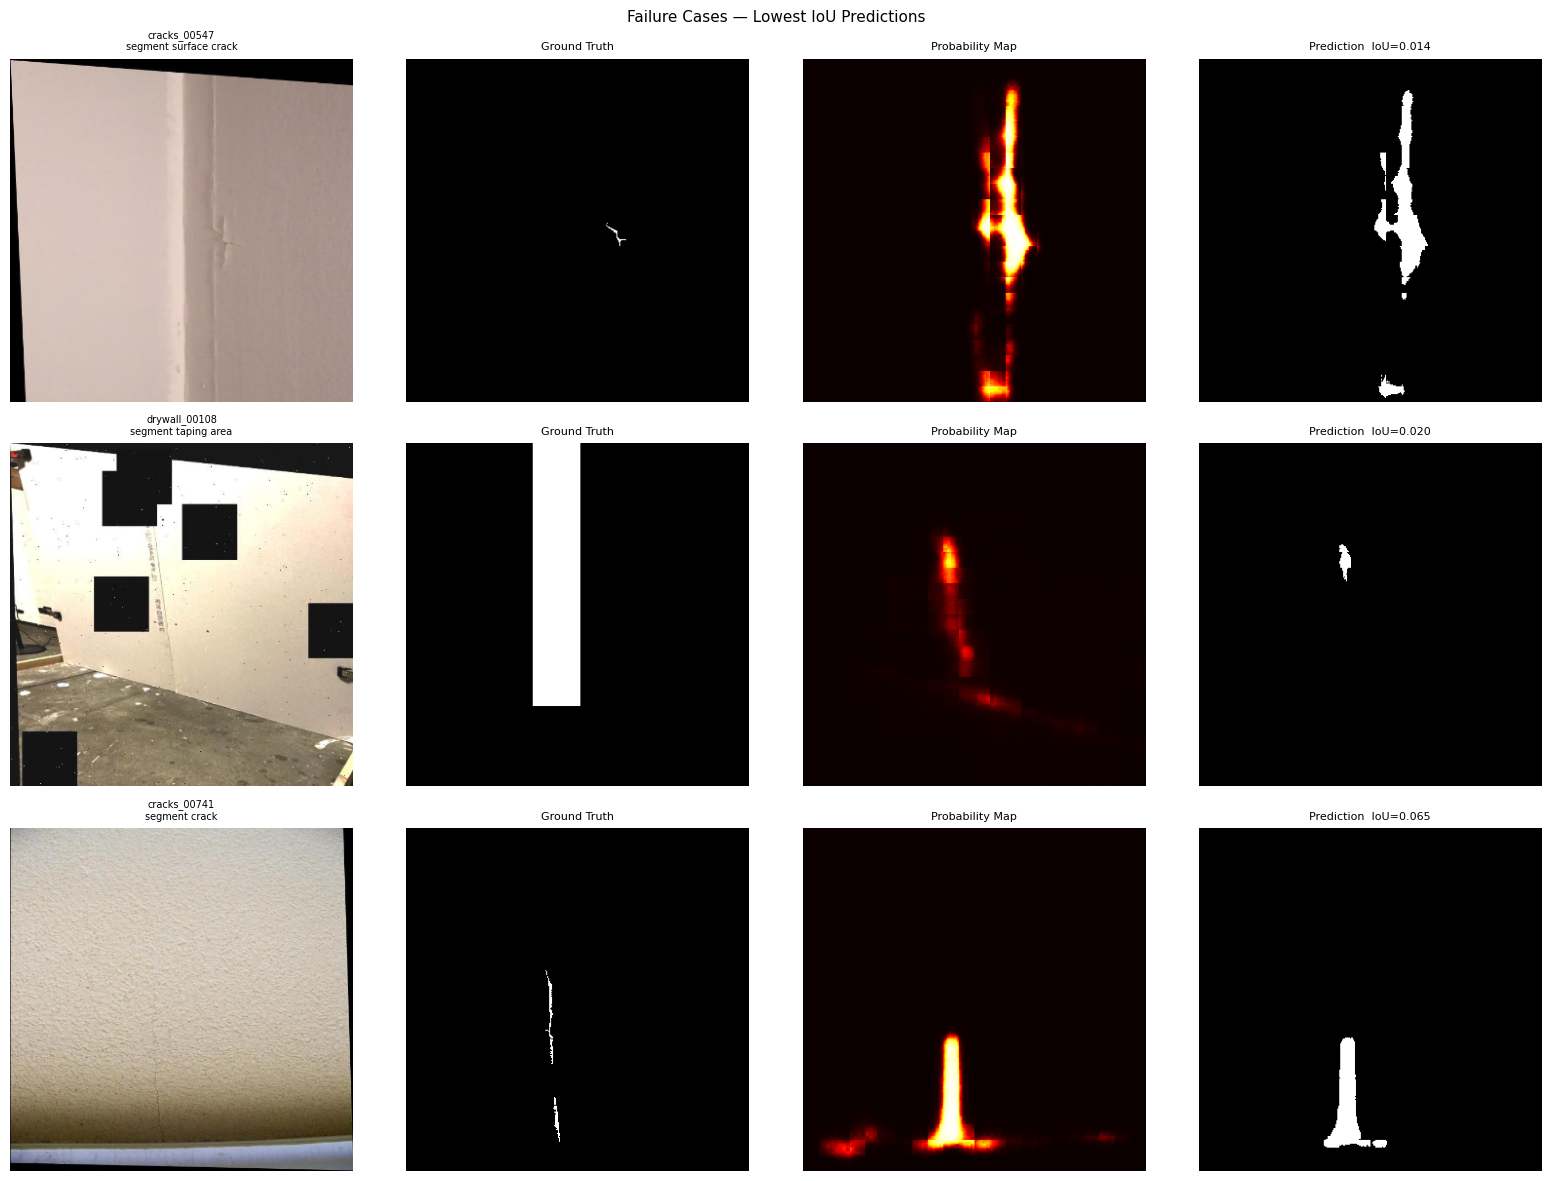

Saved → ../outputs/visualisations/clipseg/failure_cases.png


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# visualise the N worst predictions
def show_failures(
    model, worst_results, processed_root, device, prompts_df, n=3, threshold=0.5
):
    model.eval()

    # build stem - prompt map
    prompt_map = prompts_df.set_index("stem")

    fig, axes = plt.subplots(n, 4, figsize=(16, 4 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    for i, r in enumerate(worst_results[:n]):
        stem = r["stem"]
        prompt = r["prompt"]
        ds = "drywall" if stem.startswith("drywall") else "cracks"

        # load and process image
        img_path = Path(processed_root) / ds / "images" / f"{stem}.jpg"
        mask_path = Path(processed_root) / ds / "masks" / f"{stem}.png"

        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        img_resized = cv2.resize(img, (352, 352))
        mask_resized = cv2.resize(mask, (352, 352), interpolation=cv2.INTER_NEAREST)

        inputs = processor(
            images=img_resized, text=prompt, return_tensors="pt", padding=True
        )
        pv = inputs["pixel_values"].to(device)
        ids = inputs["input_ids"].to(device)

        with torch.no_grad():
            out = model(pixel_values=pv, input_ids=ids)
            logits = out.logits.unsqueeze(1).cpu()
            prob = torch.sigmoid(logits).squeeze().numpy()
            pred = (prob >= threshold).astype(float)

        gt = mask_resized / 255.0

        # display
        axes[i, 0].imshow(img_resized)
        axes[i, 0].set_title(f"{stem}\n{prompt}", fontsize=7)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(gt, cmap="gray")
        axes[i, 1].set_title("Ground Truth", fontsize=8)
        axes[i, 1].axis("off")

        axes[i, 2].imshow(prob, cmap="hot", vmin=0, vmax=1)
        axes[i, 2].set_title("Probability Map", fontsize=8)
        axes[i, 2].axis("off")

        axes[i, 3].imshow(pred, cmap="gray")
        axes[i, 3].set_title(f"Prediction  IoU={r['iou']:.3f}", fontsize=8)
        axes[i, 3].axis("off")

    plt.suptitle("Failure Cases — Lowest IoU Predictions", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{VIZ_DIR}/failure_cases.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved → {VIZ_DIR}/failure_cases.png")


show_failures(model, per_image_results, PROCESSED_ROOT, device, prompts_df, n=3)